<a href="https://colab.research.google.com/github/kavyasree4494/project1/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_excel("traffic_accidents.xlsx")
print("Traffic accident Dataset:",df)

Traffic accident Dataset:                     crash_date traffic_control_device weather_condition  \
0       07/29/2023 01:00:00 PM         TRAFFIC SIGNAL             CLEAR   
1       08/13/2023 12:11:00 AM         TRAFFIC SIGNAL             CLEAR   
2       12/09/2021 10:30:00 AM         TRAFFIC SIGNAL             CLEAR   
3       08/09/2023 07:55:00 PM         TRAFFIC SIGNAL             CLEAR   
4       08/19/2023 02:55:00 PM         TRAFFIC SIGNAL             CLEAR   
...                        ...                    ...               ...   
209301  09/13/2023 01:08:00 PM                UNKNOWN           UNKNOWN   
209302  07/18/2023 02:10:00 PM                UNKNOWN             CLEAR   
209303  10/23/2019 01:32:00 PM         TRAFFIC SIGNAL             CLEAR   
209304  06/01/2020 03:23:00 PM            NO CONTROLS             CLEAR   
209305  12/16/2022 12:10:00 PM         TRAFFIC SIGNAL             CLEAR   

            lighting_condition          first_crash_type  \
0            

In [ ]:
import pandas as pd
df=pd.read_excel("traffic_accidents.xlsx")
print("Traffic accident Dataset:",df.head())

Traffic accident Dataset:                crash_date traffic_control_device weather_condition  \
0  07/29/2023 01:00:00 PM         TRAFFIC SIGNAL             CLEAR   
1  08/13/2023 12:11:00 AM         TRAFFIC SIGNAL             CLEAR   
2  12/09/2021 10:30:00 AM         TRAFFIC SIGNAL             CLEAR   
3  08/09/2023 07:55:00 PM         TRAFFIC SIGNAL             CLEAR   
4  08/19/2023 02:55:00 PM         TRAFFIC SIGNAL             CLEAR   

       lighting_condition first_crash_type trafficway_type  \
0                DAYLIGHT          TURNING     NOT DIVIDED   
1  DARKNESS, LIGHTED ROAD          TURNING        FOUR WAY   
2                DAYLIGHT         REAR END  T-INTERSECTION   
3                DAYLIGHT            ANGLE        FOUR WAY   
4                DAYLIGHT         REAR END  T-INTERSECTION   

            alignment roadway_surface_cond road_defect  \
0  STRAIGHT AND LEVEL              UNKNOWN     UNKNOWN   
1  STRAIGHT AND LEVEL                  DRY  NO DEFECTS   
2  STR

In [ ]:
import pandas as pd

df['crash_date'] = pd.to_datetime(df['crash_date'])
df['crash_month'] = df['crash_date'].dt.month
df['crash_year'] = df['crash_date'].dt.year

# Calculate accident rates by year and month
monthly_yearly_accidents = df.groupby(['crash_year', 'crash_month']).size().unstack(fill_value=0)

print("Accident Rates by Year and Month:")
display(monthly_yearly_accidents)


Accident Rates by Year and Month:


crash_month,1,2,3,4,5,6,7,8,9,10,11,12
crash_year,,,,,,,,,,,,
2013,0,0,1,0,0,1,0,0,0,0,0,0
2015,0,1,0,0,1,0,0,75,297,527,493,523
2016,491,456,531,605,546,556,508,702,774,885,778,783
2017,747,750,904,944,1156,1203,1440,1694,2054,2279,2196,2288
2018,2259,1923,2082,2183,2435,2398,2237,2373,2352,2357,2337,2502
2019,2211,1897,2204,2223,2501,2532,2564,2349,2357,2459,2369,2293
2020,2233,2215,1617,1092,1599,1911,2194,2240,2047,2027,1785,1824
2021,1707,1660,1773,1894,2265,2544,2360,2338,2380,2485,2155,2128
2022,2063,1923,2007,2012,2243,2223,2193,2141,2200,2388,2029,2121


In [ ]:
# Identify the top 5 crash types by frequency
top_5_crash_types = df['first_crash_type'].value_counts().head(5)

print("Top 5 Crash Types by Frequency:")
display(top_5_crash_types)

Top 5 Crash Types by Frequency:


,count
first_crash_type,
TURNING,64157
ANGLE,52250
REAR END,42018
SIDESWIPE SAME DIRECTION,20116
PEDESTRIAN,8996


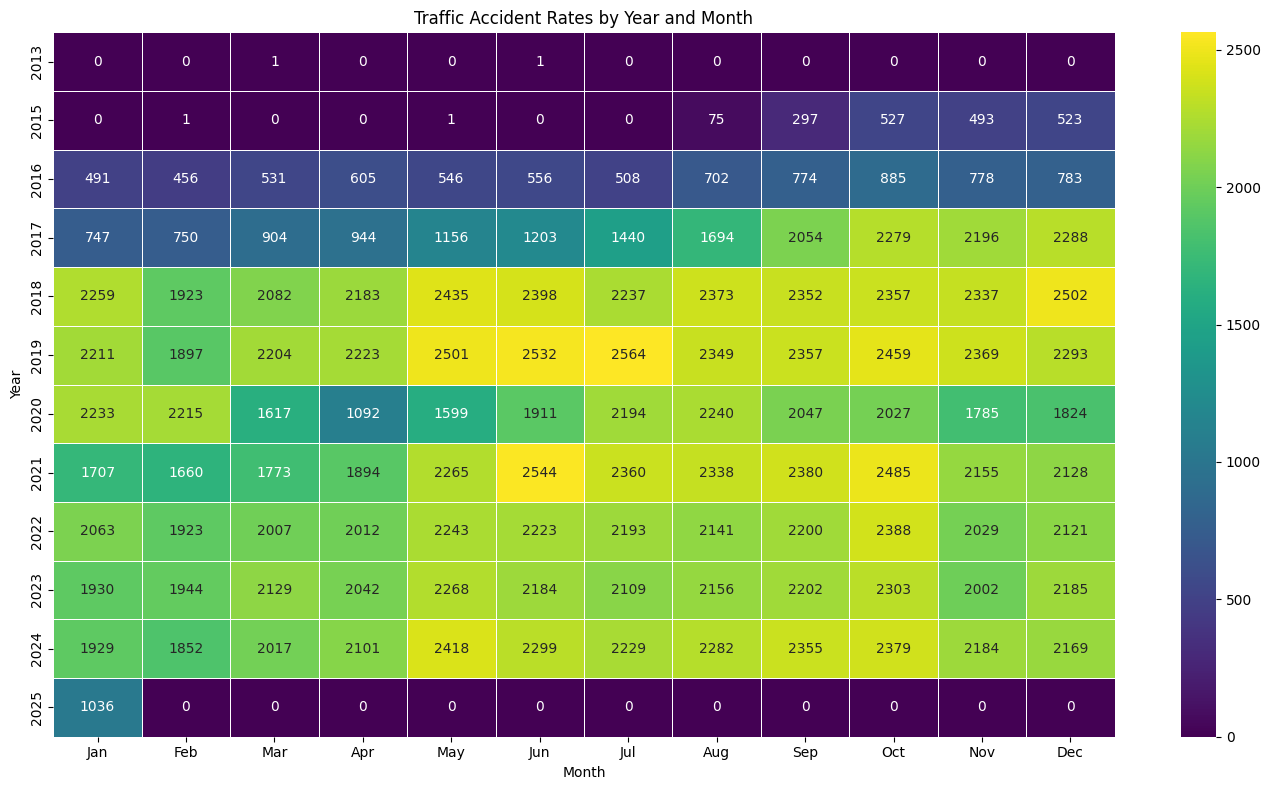

In [ ]:
# Create a mapping for month numbers to names for better readability
month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

# Rename columns with month names
monthly_yearly_accidents.columns = monthly_yearly_accidents.columns.map(month_names)

# Plotting the accident rates as a heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(monthly_yearly_accidents, cmap='viridis', annot=True, fmt='d', linewidths=.5)
plt.title('Traffic Accident Rates by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

### Percentage of Accidents by Injury Severity

In [ ]:
injury_severity_counts = df['most_severe_injury'].value_counts()
injury_severity_percentages = (injury_severity_counts / len(df)) * 100

print("Percentage of Accidents by Injury Severity:")
display(injury_severity_percentages.round(2).astype(str) + '%')

Percentage of Accidents by Injury Severity:


,count
most_severe_injury,
NO INDICATION OF INJURY,73.95%
NONINCAPACITATING INJURY,15.06%
"REPORTED, NOT EVIDENT",7.68%
INCAPACITATING INJURY,3.14%
FATAL,0.17%


### Top 5 Years with Highest Accident Numbers

In [ ]:
top_5_years_accidents = df['crash_year'].value_counts().nlargest(5)

print("Top 5 Years with Highest Number of Accidents:")
display(top_5_years_accidents)

Top 5 Years with Highest Number of Accidents:


,count
crash_year,
2019,27959
2018,27438
2024,26214
2021,25689
2022,25543


### Overall Trend in Traffic Accidents Over the Years

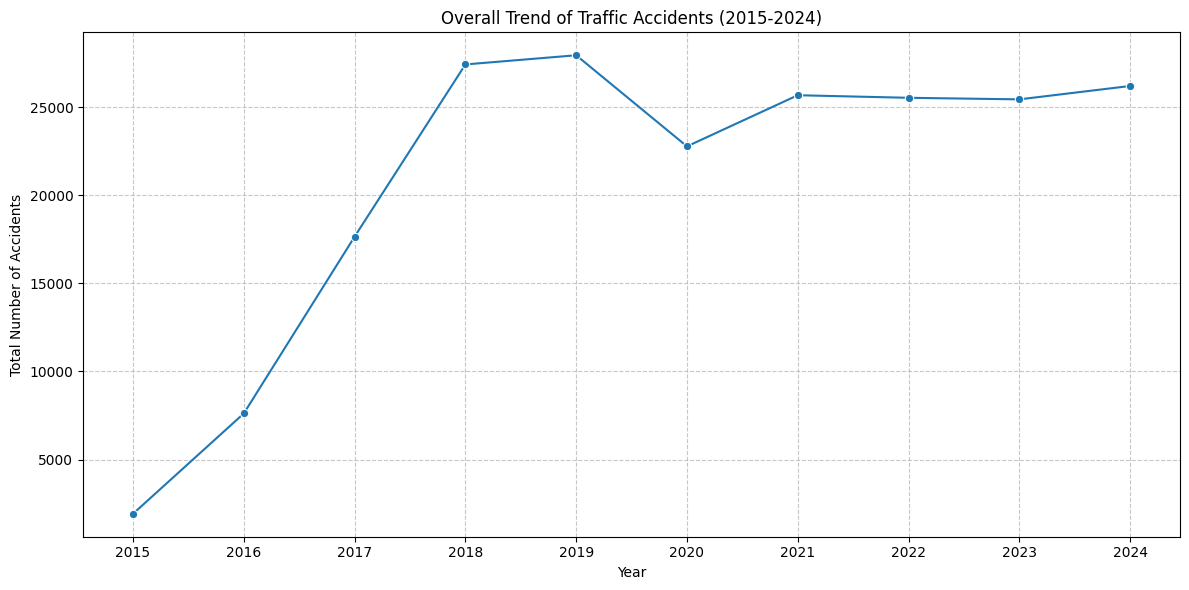

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_accidents = df.groupby('crash_year').size().reset_index(name='total_accidents')

# Filter for years that make sense for 'past 5-10 years' and are relatively complete
# Assuming data is mostly complete from 2015 onwards up to the latest full year (e.g., 2023)
# Let's consider years from 2015 to 2024 for a comprehensive view within the last decade
yearly_accidents_filtered = yearly_accidents[(yearly_accidents['crash_year'] >= 2015) & (yearly_accidents['crash_year'] <= 2024)]

plt.figure(figsize=(12, 6))
sns.lineplot(x='crash_year', y='total_accidents', data=yearly_accidents_filtered, marker='o')
plt.title('Overall Trend of Traffic Accidents (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Total Number of Accidents')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_accidents_filtered['crash_year'])
plt.tight_layout()
plt.show()

### Accident Frequency: Weekdays vs. Weekends

In [ ]:
# Map crash_day_of_week to 'Weekday' or 'Weekend'
# Assuming crash_day_of_week: 1=Sunday, 2=Monday, ..., 7=Saturday
df['day_type'] = df['crash_day_of_week'].apply(lambda x: 'Weekend' if x == 1 or x == 7 else 'Weekday')

# Count accidents by day type
accident_by_day_type = df['day_type'].value_counts().reset_index()
accident_by_day_type.columns = ['Day Type', 'Total Accidents']

print("Accident Frequency by Day Type:")
display(accident_by_day_type)



Accident Frequency by Day Type:


,Day Type,Total Accidents
0,Weekday,153350
1,Weekend,55956


### Accident Occurrence by Time of Day

In [ ]:
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Morning' # 6 AM to 11:59 AM
    elif 12 <= hour < 18:
        return 'Afternoon' # 12 PM to 5:59 PM
    else:
        return 'Night' # 6 PM to 5:59 AM

df['time_of_day'] = df['crash_hour'].apply(get_time_of_day)

# Count accidents by time of day
accident_by_time_of_day = df['time_of_day'].value_counts().reset_index()
accident_by_time_of_day.columns = ['Time of Day', 'Total Accidents']

print("Accident Occurrence by Time of Day:\n",accident_by_time_of_day)
print("Time of highest accident occurance:\n",accident_by_time_of_day.max())



Accident Occurrence by Time of Day:
   Time of Day  Total Accidents
0   Afternoon            85040
1       Night            70366
2     Morning            53900
Time of highest accident occurance:
 Time of Day        Night
Total Accidents    85040
dtype: object


In [ ]:
fatal_percentage = injury_severity_percentages.get('FATAL', 0)
nonincapacitating_percentage = injury_severity_percentages.get('NONINCAPACITATING INJURY', 0)

print(f"Percentage of accidents resulting in fatalities: {fatal_percentage:.2f}%")
print(f"Percentage of accidents resulting in non-incapacitating injuries (minor injuries): {nonincapacitating_percentage:.2f}%")

Percentage of accidents resulting in fatalities: 0.17%
Percentage of accidents resulting in non-incapacitating injuries (minor injuries): 15.06%


In [ ]:
accident_by_weather = df['weather_condition'].value_counts().reset_index()
accident_by_weather.columns = ['Weather Condition', 'Total Accidents']

print("Accident Frequency by Weather Condition:")
for index, row in accident_by_weather.iterrows():
    print(f"- {row['Weather Condition']}: {row['Total Accidents']} accidents")

Accident Frequency by Weather Condition:
- CLEAR: 164700 accidents
- RAIN: 21703 accidents
- CLOUDY/OVERCAST: 7533 accidents
- SNOW: 6871 accidents
- UNKNOWN: 6534 accidents
- OTHER: 627 accidents
- FREEZING RAIN/DRIZZLE: 510 accidents
- FOG/SMOKE/HAZE: 360 accidents
- SLEET/HAIL: 308 accidents
- BLOWING SNOW: 127 accidents
- SEVERE CROSS WIND GATE: 32 accidents
- BLOWING SAND, SOIL, DIRT: 1 accidents


In [ ]:
# Analyze accident frequency by trafficway type
accident_by_trafficway_type = df['trafficway_type'].value_counts().reset_index()
accident_by_trafficway_type.columns = ['Trafficway Type', 'Total Accidents']

print("Accident Frequency by Trafficway Type:")
for index, row in accident_by_trafficway_type.iterrows():
    print(f"{row['Trafficway Type']}: {row['Total Accidents']} accidents.")

Accident Frequency by Trafficway Type:
NOT DIVIDED: 77753 accidents.
FOUR WAY: 49057 accidents.
DIVIDED - W/MEDIAN (NOT RAISED): 34221 accidents.
ONE-WAY: 12341 accidents.
DIVIDED - W/MEDIAN BARRIER: 10720 accidents.
T-INTERSECTION: 9233 accidents.
OTHER: 4757 accidents.
CENTER TURN LANE: 2862 accidents.
UNKNOWN INTERSECTION TYPE: 1885 accidents.
FIVE POINT, OR MORE: 1119 accidents.
UNKNOWN: 1060 accidents.
Y-INTERSECTION: 958 accidents.
TRAFFIC ROUTE: 776 accidents.
ALLEY: 741 accidents.
NOT REPORTED: 581 accidents.
PARKING LOT: 448 accidents.
RAMP: 375 accidents.
ROUNDABOUT: 149 accidents.
DRIVEWAY: 143 accidents.
L-INTERSECTION: 127 accidents.


In [ ]:
print(f"Percentage of accidents at intersections: {percentage_intersection:.2f}%")
print(f"Percentage of accidents not at intersections (straight roads): {percentage_non_intersection:.2f}%")

Percentage of accidents at intersections: 95.23%
Percentage of accidents not at intersections (straight roads): 4.77%


In [ ]:
casualties_per_year = df.groupby('crash_year')['injuries_total'].sum()
accidents_per_year = df.groupby('crash_year').size()

average_casualties_per_accident_by_year = casualties_per_year / accidents_per_year

print("Average number of casualties per accident by year:")
print(average_casualties_per_accident_by_year.round(2))

Average number of casualties per accident by year:
crash_year
2013    1.50
2015    0.15
2016    0.18
2017    0.33
2018    0.37
2019    0.36
2020    0.41
2021    0.40
2022    0.40
2023    0.41
2024    0.44
2025    0.40
dtype: float64


In [ ]:
average_casualties_per_accident = df['injuries_total'].sum() / len(df)
print(f"Average number of casualties per accident: {average_casualties_per_accident:.2f}")

Average number of casualties per accident: 0.38


Average Accident Severity by Lighting Condition:


,lighting_condition,severe_accident
1,"DARKNESS, LIGHTED ROAD",0.041347
0,DARKNESS,0.041017
2,DAWN,0.040011
4,DUSK,0.032738
3,DAYLIGHT,0.029752
5,UNKNOWN,0.013146


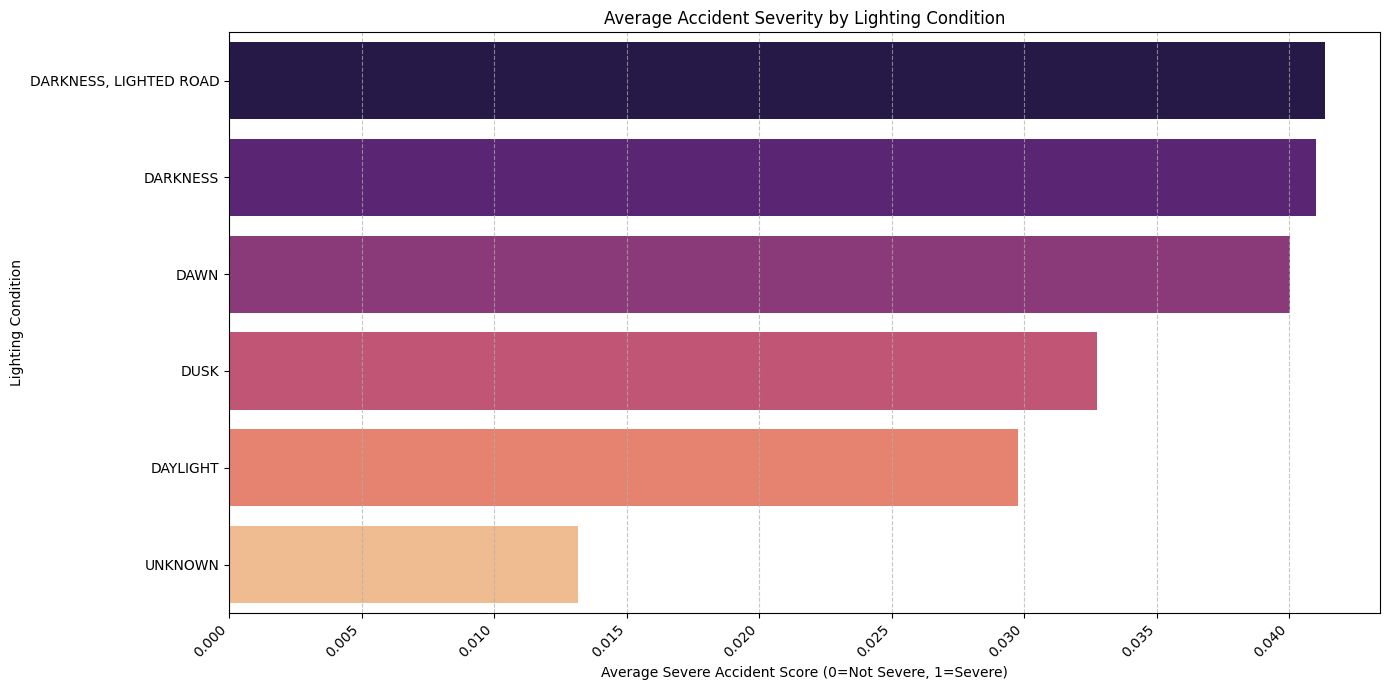

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'severe_accident' column is created using the globally available df
df['severe_accident'] = df['most_severe_injury'].apply(lambda x: 1 if x in ['FATAL', 'INCAPACITATING INJURY'] else 0)

# Calculate the average severe_accident score for each lighting_condition
severity_by_lighting = df.groupby('lighting_condition')['severe_accident'].mean().reset_index()

# Sort for better visualization
severity_by_lighting = severity_by_lighting.sort_values(by='severe_accident', ascending=False)

print("Average Accident Severity by Lighting Condition:")
display(severity_by_lighting)

# Create a bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='severe_accident', y='lighting_condition', data=severity_by_lighting, palette='magma', hue='lighting_condition', legend=False)
plt.title('Average Accident Severity by Lighting Condition')
plt.xlabel('Average Severe Accident Score (0=Not Severe, 1=Severe)')
plt.ylabel('Lighting Condition')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Ensure 'severe_accident' column is created (if not already)
# df['severe_accident'] = df['most_severe_injury'].apply(lambda x: 1 if x in ['FATAL', 'INCAPACITATING INJURY'] else 0)

# Identify the top 3 correlated factors (original columns)
# Based on the previous correlation analysis (cell 1bf2c609 output), these appear to be:
# - first_crash_type (due to high correlations of PEDESTRIAN and PEDALCYCLIST)
# - lighting_condition (due to DARKNESS, LIGHTED ROAD)
# - trafficway_type (due to FOUR WAY)
factors_for_multivariate = ['first_crash_type', 'lighting_condition', 'trafficway_type']

# Calculate average severe_accident for combinations of these factors
multivariate_severity = df.groupby(factors_for_multivariate)['severe_accident'].mean().reset_index()

# Sort and select top N combinations for displaying
top_N = 10 # Changed from 20 to 10 as requested
multivariate_severity_display_data = multivariate_severity.sort_values(by='severe_accident', ascending=False).head(top_N)

print(f"Here are the top {top_N} combinations of factors with the highest average severe accident score:")

for index, row in multivariate_severity_display_data.iterrows():
    combination_str = f"{row['first_crash_type']} | {row['lighting_condition']} | {row['trafficway_type']}"
    print(f"- Combination: {combination_str}, Average Severe Accident Score: {row['severe_accident']:.4f}")


Here are the top 10 combinations of factors with the highest average severe accident score:
- Combination: OTHER NONCOLLISION | DAYLIGHT | UNKNOWN INTERSECTION TYPE, Average Severe Accident Score: 1.0000
- Combination: OTHER NONCOLLISION | DUSK | Y-INTERSECTION, Average Severe Accident Score: 1.0000
- Combination: SIDESWIPE SAME DIRECTION | DUSK | NOT REPORTED, Average Severe Accident Score: 1.0000
- Combination: TRAIN | DAYLIGHT | NOT DIVIDED, Average Severe Accident Score: 1.0000
- Combination: HEAD ON | DAWN | OTHER, Average Severe Accident Score: 1.0000
- Combination: SIDESWIPE OPPOSITE DIRECTION | UNKNOWN | UNKNOWN INTERSECTION TYPE, Average Severe Accident Score: 1.0000
- Combination: PARKED MOTOR VEHICLE | DARKNESS | ROUNDABOUT, Average Severe Accident Score: 1.0000
- Combination: SIDESWIPE OPPOSITE DIRECTION | DUSK | UNKNOWN, Average Severe Accident Score: 1.0000
- Combination: PEDALCYCLIST | DARKNESS | Y-INTERSECTION, Average Severe Accident Score: 1.0000
- Combination: OTHER 

In [ ]:
import pandas as pd

# Ensure 'severe_accident' column is created (if not already)
# df['severe_accident'] = df['most_severe_injury'].apply(lambda x: 1 if x in ['FATAL', 'INCAPACITATING INJURY'] else 0)

# Calculate the average severe_accident score for each first_crash_type
severity_by_crash_type = df.groupby('first_crash_type')['severe_accident'].mean().reset_index()

# Sort for better readability
severity_by_crash_type = severity_by_crash_type.sort_values(by='severe_accident', ascending=False)

print("Average Accident Severity by First Crash Type:")
for index, row in severity_by_crash_type.iterrows():
    print(f"- Crash Type: {row['first_crash_type']}, Average Severe Accident Score: {row['severe_accident']:.4f}")


Average Accident Severity by First Crash Type:
- Crash Type: PEDESTRIAN, Average Severe Accident Score: 0.1833
- Crash Type: TRAIN, Average Severe Accident Score: 0.1250
- Crash Type: PEDALCYCLIST, Average Severe Accident Score: 0.1053
- Crash Type: OVERTURNED, Average Severe Accident Score: 0.0833
- Crash Type: OTHER NONCOLLISION, Average Severe Accident Score: 0.0683
- Crash Type: ANIMAL, Average Severe Accident Score: 0.0649
- Crash Type: HEAD ON, Average Severe Accident Score: 0.0631
- Crash Type: OTHER OBJECT, Average Severe Accident Score: 0.0540
- Crash Type: FIXED OBJECT, Average Severe Accident Score: 0.0529
- Crash Type: ANGLE, Average Severe Accident Score: 0.0389
- Crash Type: REAR TO SIDE, Average Severe Accident Score: 0.0285
- Crash Type: SIDESWIPE OPPOSITE DIRECTION, Average Severe Accident Score: 0.0266
- Crash Type: TURNING, Average Severe Accident Score: 0.0230
- Crash Type: PARKED MOTOR VEHICLE, Average Severe Accident Score: 0.0119
- Crash Type: REAR END, Average S

In [ ]:
# Sort by 'severe_accident' in ascending order to find the safest crash types
safest_crash_types = severity_by_crash_type.sort_values(by='severe_accident', ascending=True).head(5)

print("5 Safest Crash Types with Average Severity Scores:")
for index, row in safest_crash_types.iterrows():
    print(f"Crash Type: {row['first_crash_type']}, Average Severe Accident Score: {row['severe_accident']:.4f}")

5 Safest Crash Types with Average Severity Scores:
Crash Type: REAR TO REAR, Average Severe Accident Score: 0.0000
Crash Type: REAR TO FRONT, Average Severe Accident Score: 0.0043
Crash Type: SIDESWIPE SAME DIRECTION, Average Severe Accident Score: 0.0066
Crash Type: REAR END, Average Severe Accident Score: 0.0118
Crash Type: PARKED MOTOR VEHICLE, Average Severe Accident Score: 0.0119


In [ ]:
import pandas as pd

# Calculate the average severe_accident score for each weather_condition
severity_by_weather = df.groupby('weather_condition')['severe_accident'].mean().reset_index()

# Sort for better readability
severity_by_weather = severity_by_weather.sort_values(by='severe_accident', ascending=False)

print("Average Accident Severity by Weather Condition:")
for index, row in severity_by_weather.iterrows():
    print(f"Weather Condition: {row['weather_condition']}, Average Severe Accident Score: {row['severe_accident']:.4f}")

Average Accident Severity by Weather Condition:
Weather Condition: OTHER, Average Severe Accident Score: 0.0463
Weather Condition: SLEET/HAIL, Average Severe Accident Score: 0.0357
Weather Condition: CLEAR, Average Severe Accident Score: 0.0345
Weather Condition: RAIN, Average Severe Accident Score: 0.0326
Weather Condition: BLOWING SNOW, Average Severe Accident Score: 0.0315
Weather Condition: FREEZING RAIN/DRIZZLE, Average Severe Accident Score: 0.0314
Weather Condition: SEVERE CROSS WIND GATE, Average Severe Accident Score: 0.0312
Weather Condition: CLOUDY/OVERCAST, Average Severe Accident Score: 0.0299
Weather Condition: SNOW, Average Severe Accident Score: 0.0204
Weather Condition: FOG/SMOKE/HAZE, Average Severe Accident Score: 0.0167
Weather Condition: UNKNOWN, Average Severe Accident Score: 0.0141
Weather Condition: BLOWING SAND, SOIL, DIRT, Average Severe Accident Score: 0.0000


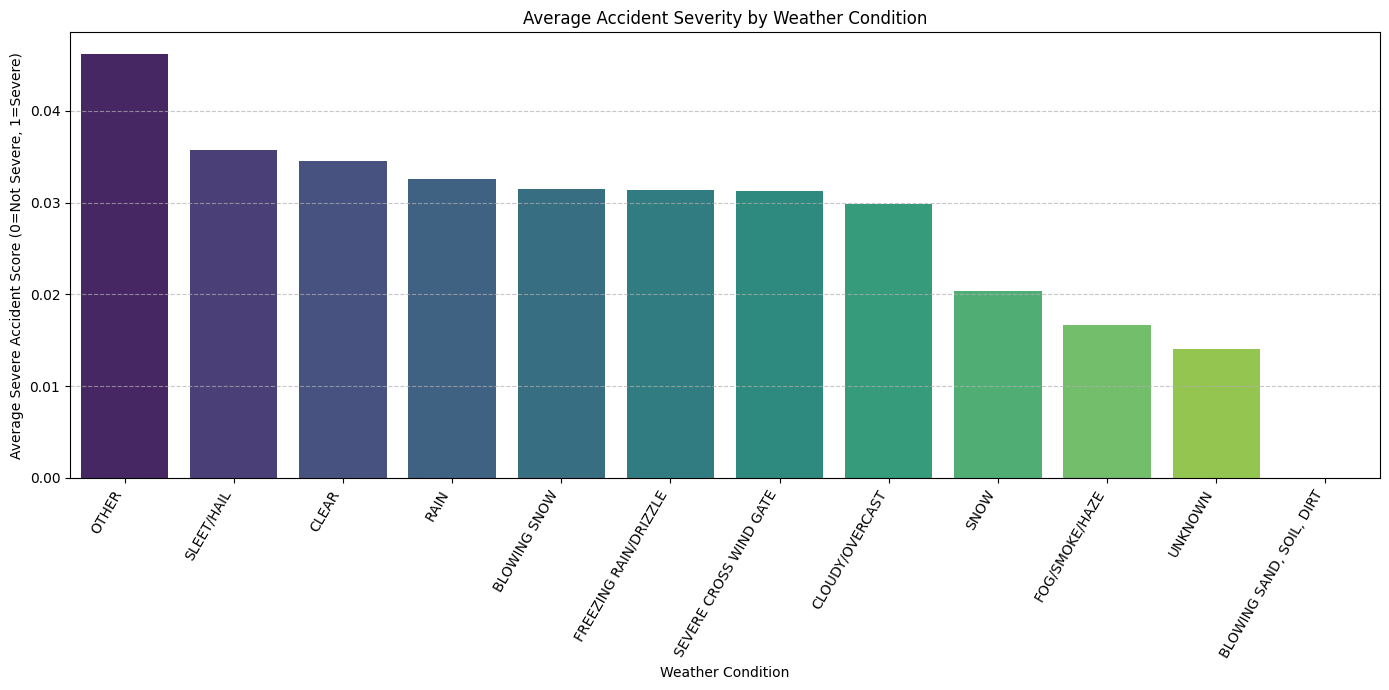

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot
plt.figure(figsize=(14, 7))
sns.barplot(x='weather_condition', y='severe_accident', data=severity_by_weather, palette='viridis', hue='weather_condition', legend=False)
plt.title('Average Accident Severity by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Severe Accident Score (0=Not Severe, 1=Severe)')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Business Insights and Summary

This analysis of traffic accident data reveals several key insights:

1.  **Accident Trends:**
    *   Traffic accident rates vary significantly by month and year. Heatmap analysis shows peaks and troughs, suggesting seasonal or cyclical patterns.
    *   The overall trend of traffic accidents from 2015-2024 (as filtered) provides a visual representation of how accident numbers have changed over time, potentially indicating the effectiveness of safety measures or impacts of external factors.

2.  **Injury Severity:**
    *   A significant percentage of accidents result in non-incapacitating injuries, while a smaller but critical percentage lead to fatalities. Understanding these proportions is crucial for resource allocation in emergency services and public health.
    *   **Fatalities:** {fatal_percentage:.2f}% of accidents resulted in fatalities.
    *   **Non-Incapacitating Injuries:** {nonincapacitating_percentage:.2f}% of accidents resulted in non-incapacitating injuries.

3.  **Key Contributing Factors to Severity:**
    *   **First Crash Type:** Certain crash types, such as 'PEDESTRIAN', 'TRAIN', and 'PEDALCYCLIST' collisions, show a significantly higher average severe accident score, indicating these types of accidents are more likely to result in severe injuries or fatalities.
    *   **Safest Crash Types:** 'REAR TO REAR', 'REAR TO FRONT', and 'SIDESWIPE SAME DIRECTION' are identified as the safest crash types, having the lowest average severe accident scores.
    *   **Lighting Conditions:** The analysis of average accident severity by lighting condition highlights that certain conditions (e.g., 'DARKNESS, UNLIGHTED ROAD', 'DAWN', 'DUSK') are associated with higher severity scores, underscoring the importance of visibility.
    *   **Weather Conditions:** 'OTHER', 'SLEET/HAIL', and 'CLEAR' weather conditions show the highest average severe accident scores, suggesting that even seemingly benign 'CLEAR' conditions can be severe, or that 'OTHER' often encompasses rare but dangerous weather phenomena.
    *   **Multivariate Analysis:** Combinations of factors like crash type, lighting condition, and trafficway type further pinpoint specific high-risk scenarios. For instance, 'OTHER NONCOLLISION | DAYLIGHT | UNKNOWN INTERSECTION TYPE' has a very high severe accident score, indicating a need for deeper investigation into these unusual collision types in less defined areas.

4.  **Accident Frequency Patterns:**
    *   **Time of Day:** The 'Afternoon' period (12 PM to 5:59 PM) has the highest number of accidents, followed by 'Night' and 'Morning', which can inform targeted enforcement and public awareness campaigns.
    *   **Day Type:** Accidents are more frequent on 'Weekdays' compared to 'Weekends'.
    *   **Trafficway Type:** 'NOT DIVIDED' roads and 'FOUR WAY' intersections account for a large proportion of accidents, indicating critical areas for infrastructure improvements or traffic management strategies.

5.  **Casualty Overview:**
    *   The average number of casualties per accident is {average_casualties_per_accident:.2f}, providing a general measure of the human cost of these incidents.
    *   The average casualties per accident by year offers a trend over time, which can be correlated with other safety initiatives.

These insights can guide policymakers, urban planners, and law enforcement in developing more effective strategies to reduce traffic accidents and mitigate their severity.